# Regularized Regression in R

## Overview

Regularized regression adds a penalty term to the loss function that shrinks coefficient estimates toward zero. This reduces overfitting, handles multicollinearity, and performs automatic variable selection — making it the standard approach when the number of predictors is large relative to n, or when predictors are highly correlated.

| Method | Penalty | Effect |
|---|---|---|
| **Ridge (L2)** | Sum of squared coefficients (β²) | Shrinks all coefficients toward zero; none exactly zero; handles multicollinearity well |
| **Lasso (L1)** | Sum of absolute coefficients (\|β\|) | Shrinks some coefficients to exactly zero; performs variable selection |
| **Elastic net** | Weighted combination of L1 + L2 | Balances ridge and lasso; preferred when predictors are correlated and selection is needed |

> **Choosing between them:**  
> - Many predictors, expect most to matter → Ridge  
> - Many predictors, expect only a few to matter → Lasso  
> - Correlated predictors and want selection → Elastic net  
> - Unsure → try elastic net first

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Predicting invertebrate diversity from a large set of correlated water chemistry variables; selecting the most important habitat features from a wide survey instrument |
| **Healthcare** | Predicting patient outcomes from high-dimensional clinical data with many correlated biomarkers; selecting predictors from electronic health record feature sets |
| **Finance** | Building a credit scoring model from many correlated financial ratios; predicting asset returns from a large factor set |
| **Insurance** | Selecting predictive features for claim frequency models from wide policyholder feature sets; handling correlated demographic and risk variables |

---

## Assumptions Checklist

Regularized regression inherits the structural assumptions of linear or logistic regression, with some important differences:

- [ ] **Response type matches model family:** Continuous → gaussian; binary → binomial; count → poisson
- [ ] **Predictors are scaled:** `glmnet` requires predictors to be on the same scale — standardize before fitting (done automatically by default in `glmnet`)
- [ ] **Lambda selected by cross-validation:** Never choose the penalty parameter on the training data; always use CV
- [ ] **No data leakage:** Scaling parameters (mean, SD) must be estimated on training data only and applied to test data
- [ ] **Interpretability caveat:** Regularized coefficients are biased by design — they are optimized for prediction, not unbiased estimation. Do not interpret shrunk coefficients as you would OLS coefficients.

> **Regularized regression does NOT fix:**  
> Non-independence of observations (use mixed models), non-linearity (use GAMs or tree models), or non-normal residuals in linear regression (use appropriate GLM family)

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)
library(ggplot2)
library(glmnet)       # ridge, lasso, and elastic net via penalized GLMs
library(caret)        # cross-validation framework
library(broom)        # tidy model output
library(vip)          # variable importance plots

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, 

## Data

We simulate a dataset with 20 predictors (many correlated) and a continuous response. This mirrors real scenarios where a large feature set needs to be reduced for a predictive model — water chemistry panels, clinical labs, financial ratios.

In [2]:
# ── Simulate high-dimensional data with correlated predictors ─────────────────
n  <- 200
p  <- 20   # number of predictors

# Correlated predictor matrix (mimics a water chemistry panel)
sigma     <- matrix(0.5, p, p); diag(sigma) <- 1
X_raw     <- MASS::mvrnorm(n, mu = rep(0, p), Sigma = sigma)
colnames(X_raw) <- paste0("var", 1:p)

# Only 5 of 20 predictors truly matter
true_betas <- c(1.5, -1.2, 0.8, 0, 0, -0.6, 0, 0, 0, 0.9,
                rep(0, 10))
y <- X_raw %*% true_betas + rnorm(n, 0, 1.5)

# Combine into data frame
sim_data <- as.data.frame(X_raw) %>% mutate(response = as.numeric(y))

cat(sprintf("Dataset: %d observations, %d predictors\n", n, p))
cat("True non-zero predictors: var1, var2, var3, var6, var10\n")

# ── Train/test split ──────────────────────────────────────────────────────────
train_idx  <- sample(1:n, size = floor(0.8 * n))
train_data <- sim_data[train_idx, ]
test_data  <- sim_data[-train_idx, ]

# ── glmnet requires matrix input ──────────────────────────────────────────────
X_train <- as.matrix(train_data[, paste0("var", 1:p)])
y_train <- train_data$response
X_test  <- as.matrix(test_data[, paste0("var", 1:p)])
y_test  <- test_data$response

# glmnet standardizes predictors internally by default (standardize = TRUE)
# Coefficients are returned on original scale

Dataset: 200 observations, 20 predictors
True non-zero predictors: var1, var2, var3, var6, var10


---

## Ridge Regression (L2)

Shrinks all coefficients toward zero but never to exactly zero. Best when most predictors contribute to the response and multicollinearity is present.

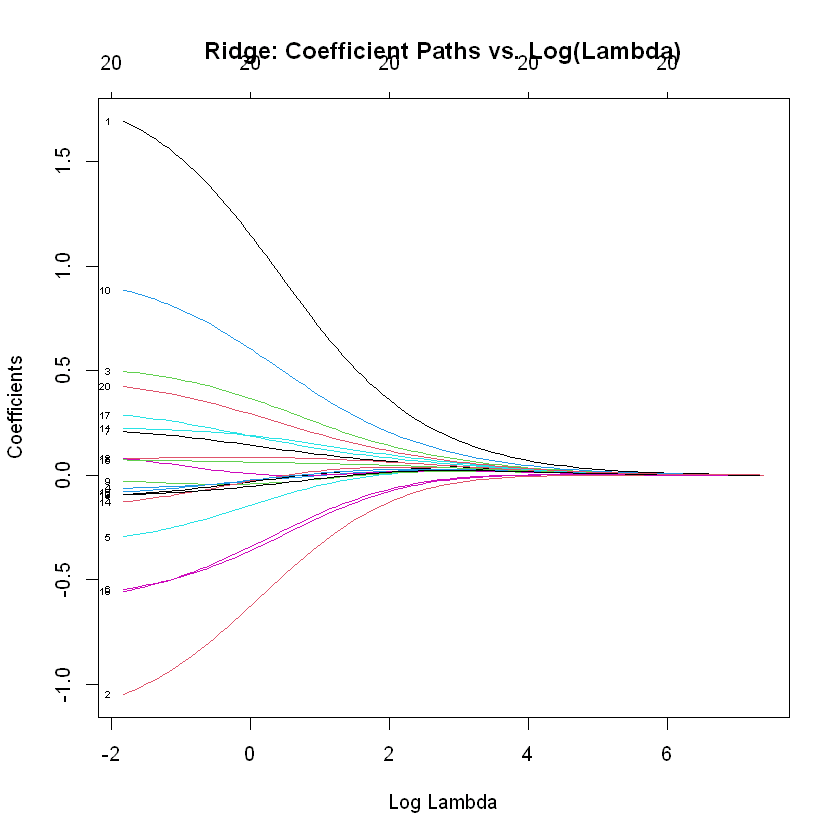

lambda.min = 0.1611 | lambda.1se = 0.7138
21 x 1 sparse Matrix of class "dgCMatrix"
                 s1
(Intercept) -0.2223
var1         1.2887
var2        -0.7265
var3         0.4022
var4        -0.0372
var5        -0.1782
var6        -0.4092
var7         0.1592
var8         0.0856
var9        -0.0435
var10        0.6756
var11        0.2008
var12        0.0179
var13       -0.0458
var14       -0.0494
var15        0.0651
var16       -0.0359
var17        0.2106
var18       -0.3949
var19       -0.0641
var20        0.3249
Ridge — Test RMSE: 1.453 | Test R²: 0.580


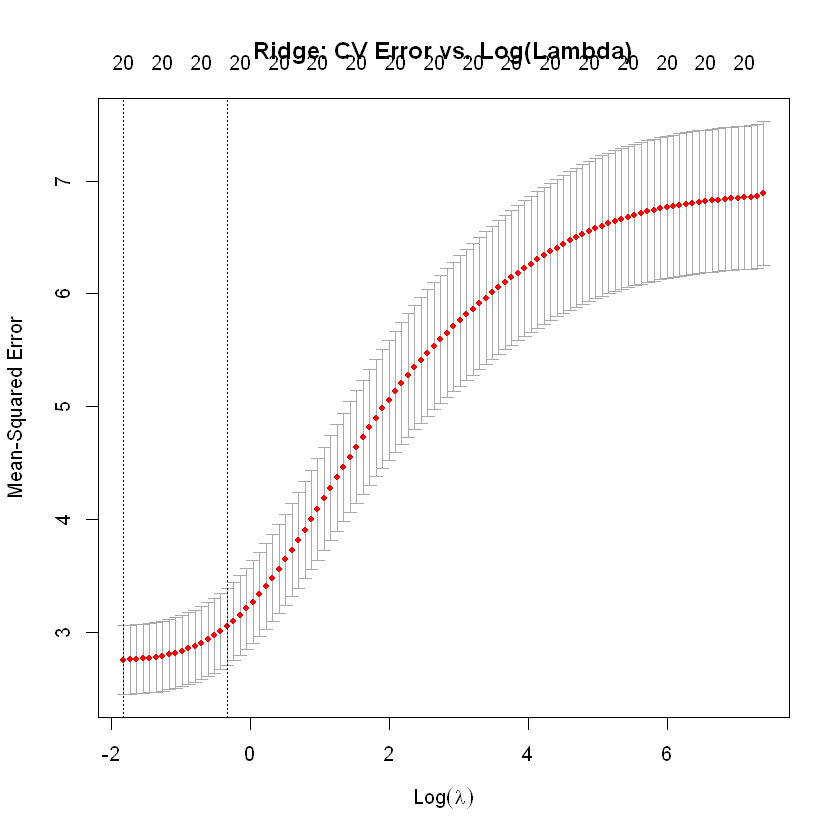

In [3]:
# ── Fit ridge over grid of lambda values ──────────────────────────────────────
# alpha = 0 → ridge; alpha = 1 → lasso; 0 < alpha < 1 → elastic net
ridge_fit <- glmnet(X_train, y_train, alpha = 0, family = "gaussian")

# ── Coefficient path plot ────────────────────────────────────────────────────
plot(ridge_fit, xvar = "lambda", label = TRUE,
     main = "Ridge: Coefficient Paths vs. Log(Lambda)")
# All coefficients shrink toward 0 as lambda increases
# but none reach exactly 0 (ridge property)

# ── Select optimal lambda via cross-validation ────────────────────────────────
ridge_cv <- cv.glmnet(X_train, y_train, alpha = 0, nfolds = 10)
plot(ridge_cv, main = "Ridge: CV Error vs. Log(Lambda)")

# Two standard lambda choices:
lambda_min <- ridge_cv$lambda.min    # minimizes CV error
lambda_1se <- ridge_cv$lambda.1se    # largest lambda within 1 SE of minimum
                                     # more regularized, often preferred
cat(sprintf("lambda.min = %.4f | lambda.1se = %.4f\n", lambda_min, lambda_1se))

# ── Final ridge model at lambda.1se ──────────────────────────────────────────
ridge_coefs <- coef(ridge_cv, s = "lambda.1se")
print(round(ridge_coefs, 4))

# ── Test set performance ──────────────────────────────────────────────────────
ridge_pred <- predict(ridge_cv, newx = X_test, s = "lambda.1se")
ridge_rmse <- sqrt(mean((y_test - ridge_pred)^2))
ridge_r2   <- cor(y_test, ridge_pred)^2
cat(sprintf("Ridge — Test RMSE: %.3f | Test R²: %.3f\n", ridge_rmse, ridge_r2))

---

## Lasso Regression (L1)

Shrinks some coefficients to exactly zero, performing automatic variable selection. Best when you believe only a subset of predictors truly matter.

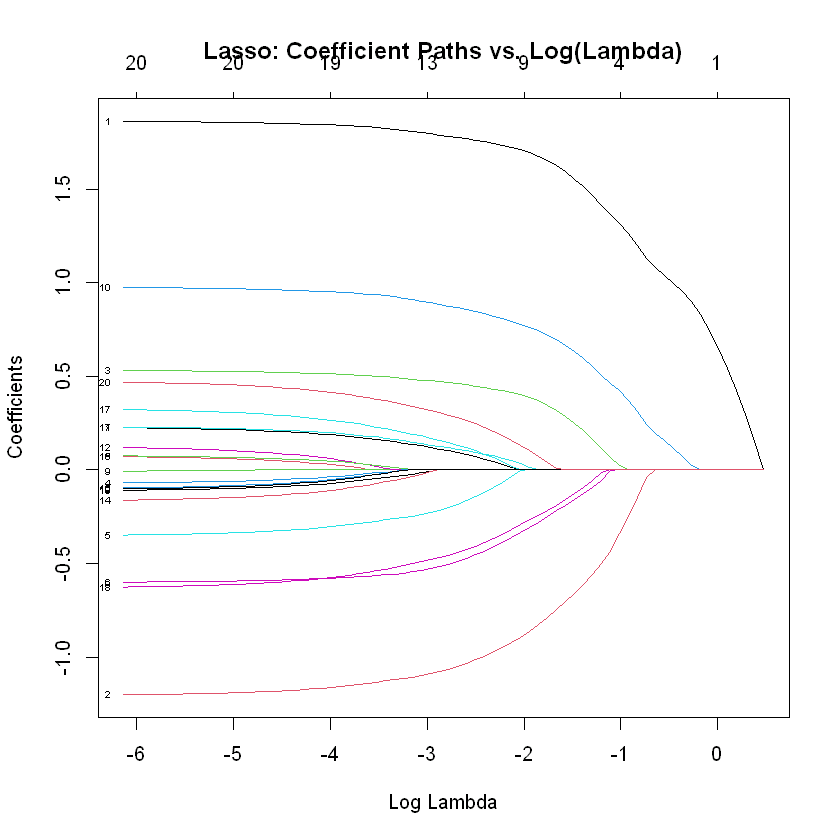

Non-zero coefficients selected by lasso:
7 x 1 sparse Matrix of class "dgCMatrix"
                 s1
(Intercept) -0.2390
var1         1.5926
var2        -0.7037
var3         0.2866
var6        -0.1879
var10        0.6663
var18       -0.1591
Lasso — Test RMSE: 1.495 | Test R²: 0.567


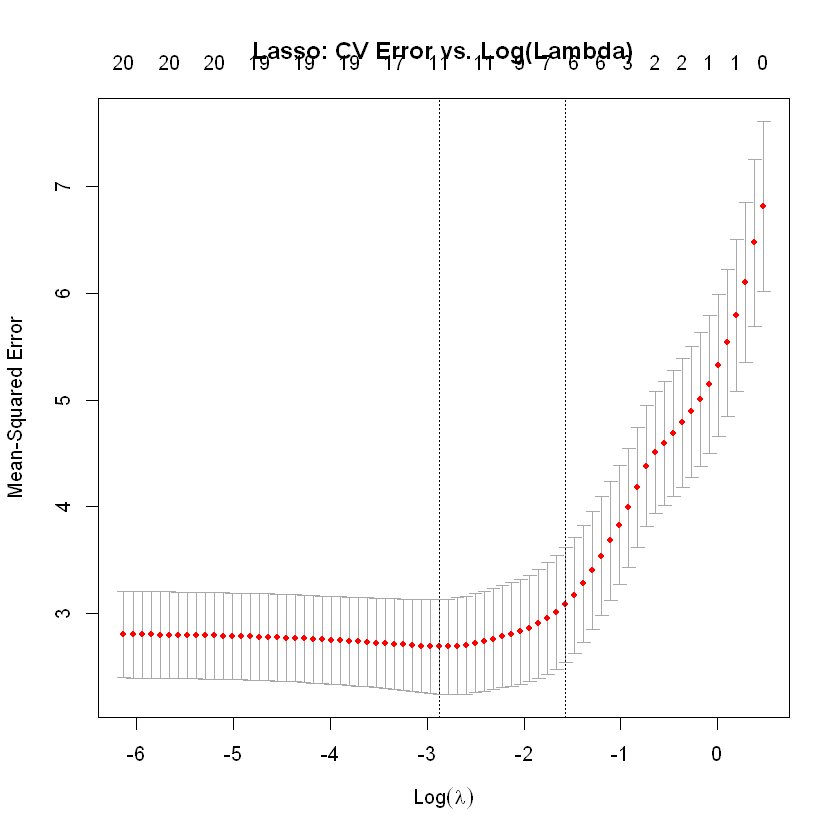

In [4]:
# ── Fit lasso via cross-validation ───────────────────────────────────────────
lasso_cv <- cv.glmnet(X_train, y_train, alpha = 1, nfolds = 10)

# ── Coefficient path ──────────────────────────────────────────────────────────
plot(lasso_cv$glmnet.fit, xvar = "lambda", label = TRUE,
     main = "Lasso: Coefficient Paths vs. Log(Lambda)")
# Coefficients drop to exactly 0 as lambda increases
# Numbers at top = number of non-zero coefficients at each lambda

plot(lasso_cv, main = "Lasso: CV Error vs. Log(Lambda)")

# ── Selected variables at lambda.1se ─────────────────────────────────────────
lasso_coefs <- coef(lasso_cv, s = "lambda.1se")
selected    <- lasso_coefs[lasso_coefs[, 1] != 0, , drop = FALSE]
cat("Non-zero coefficients selected by lasso:\n")
print(round(selected, 4))
# Compare to true non-zero: var1, var2, var3, var6, var10

# ── Test set performance ──────────────────────────────────────────────────────
lasso_pred <- predict(lasso_cv, newx = X_test, s = "lambda.1se")
lasso_rmse <- sqrt(mean((y_test - lasso_pred)^2))
lasso_r2   <- cor(y_test, lasso_pred)^2
cat(sprintf("Lasso — Test RMSE: %.3f | Test R²: %.3f\n", lasso_rmse, lasso_r2))

---

## Elastic Net

Combines L1 and L2 penalties. The `alpha` parameter controls the mix: alpha = 1 is lasso, alpha = 0 is ridge. Values between 0 and 1 blend both. Tuning alpha via an outer cross-validation loop is best practice.

In [5]:
# ── Tune alpha and lambda simultaneously ──────────────────────────────────────
# Outer loop: try multiple alpha values
# Inner loop: cv.glmnet selects best lambda for each alpha
alpha_grid  <- seq(0, 1, by = 0.1)
enet_results <- map_dfr(alpha_grid, function(a) {
  cv_fit <- cv.glmnet(X_train, y_train, alpha = a, nfolds = 10)
  tibble(
    alpha      = a,
    lambda_min = cv_fit$lambda.min,
    lambda_1se = cv_fit$lambda.1se,
    cvm_min    = min(cv_fit$cvm)  # minimum CV mean squared error
  )
})

print(enet_results)
best_alpha <- enet_results$alpha[which.min(enet_results$cvm_min)]
cat(sprintf("\nBest alpha: %.1f\n", best_alpha))

# ── Fit final elastic net with best alpha ─────────────────────────────────────
enet_cv <- cv.glmnet(X_train, y_train, alpha = best_alpha, nfolds = 10)

enet_coefs <- coef(enet_cv, s = "lambda.1se")
enet_selected <- enet_coefs[enet_coefs[, 1] != 0, , drop = FALSE]
cat("Non-zero coefficients selected by elastic net:\n")
print(round(enet_selected, 4))

# ── Test set performance ──────────────────────────────────────────────────────
enet_pred <- predict(enet_cv, newx = X_test, s = "lambda.1se")
enet_rmse <- sqrt(mean((y_test - enet_pred)^2))
enet_r2   <- cor(y_test, enet_pred)^2
cat(sprintf("Elastic Net — Test RMSE: %.3f | Test R²: %.3f\n", enet_rmse, enet_r2))

# A tibble: 11 × 4
   alpha lambda_min lambda_1se cvm_min
   <dbl>      <dbl>      <dbl>   <dbl>
 1   0       0.161       0.714    2.73
 2   0.1     0.128       0.621    2.80
 3   0.2     0.195       0.450    2.69
 4   0.3     0.143       0.300    2.66
 5   0.4     0.129       0.327    2.62
 6   0.5     0.124       0.261    2.68
 7   0.6     0.0943      0.239    2.67
 8   0.7     0.0671      0.187    2.62
 9   0.8     0.0852      0.179    2.65
10   0.9     0.0629      0.175    2.71
11   1       0.0621      0.173    2.74

Best alpha: 0.7
Non-zero coefficients selected by elastic net:
8 x 1 sparse Matrix of class "dgCMatrix"
                 s1
(Intercept) -0.2382
var1         1.6067
var2        -0.7739
var3         0.3584
var6        -0.2656
var10        0.7174
var18       -0.2277
var20        0.0803
Elastic Net — Test RMSE: 1.479 | Test R²: 0.583


---

## Model Comparison

# A tibble: 4 × 4
  Model       Test_RMSE Test_R2[,1] N_Predictors
  <chr>           <dbl>       <dbl>        <dbl>
1 OLS              1.67       0.58            20
2 Ridge            1.45       0.58            20
3 Lasso            1.50       0.567            6
4 Elastic Net      1.48       0.583            7


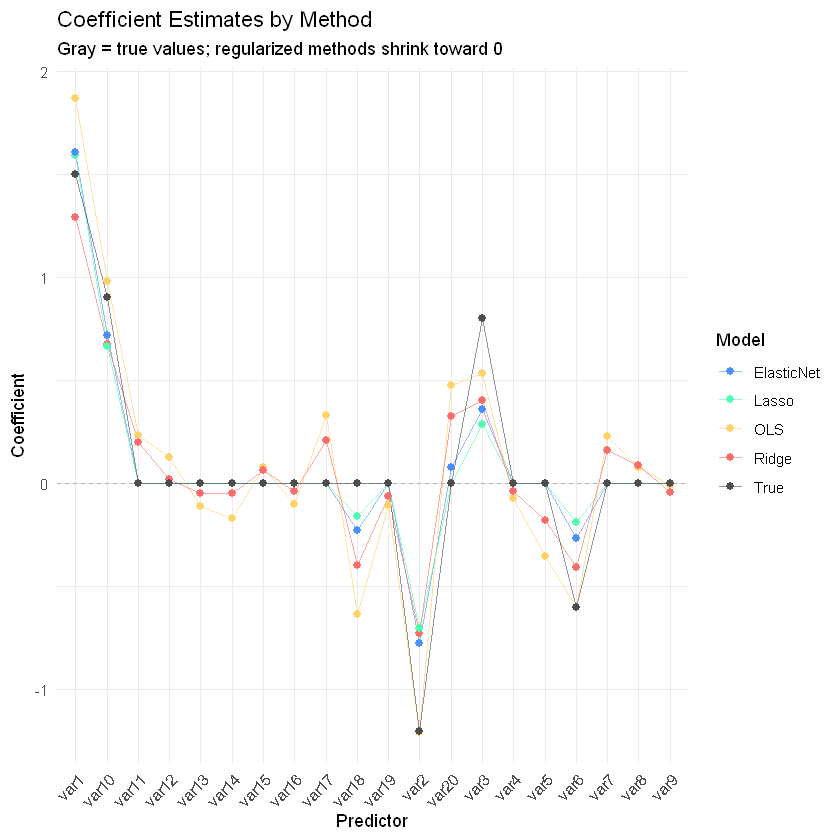

In [6]:
# ── OLS benchmark ────────────────────────────────────────────────────────────
ols_fit  <- lm(response ~ ., data = train_data)
ols_pred <- predict(ols_fit, newdata = test_data)
ols_rmse <- sqrt(mean((y_test - ols_pred)^2))
ols_r2   <- cor(y_test, ols_pred)^2

# ── Summary comparison table ──────────────────────────────────────────────────
comparison <- tribble(
  ~Model,          ~Test_RMSE,  ~Test_R2,   ~N_Predictors,
  "OLS",           ols_rmse,    ols_r2,     p,
  "Ridge",         ridge_rmse,  ridge_r2,   p,           # ridge keeps all
  "Lasso",         lasso_rmse,  lasso_r2,   sum(lasso_coefs[-1] != 0),
  "Elastic Net",   enet_rmse,   enet_r2,    sum(enet_coefs[-1] != 0)
)
print(comparison %>% mutate(across(where(is.numeric), ~ round(.x, 3))))

# ── Coefficient comparison plot ───────────────────────────────────────────────
coef_df <- tibble(
  predictor = paste0("var", 1:p),
  OLS       = coef(ols_fit)[-1],
  Ridge     = as.numeric(ridge_coefs)[-1],
  Lasso     = as.numeric(lasso_coefs)[-1],
  ElasticNet = as.numeric(enet_coefs)[-1],
  True      = true_betas
) %>%
  pivot_longer(-predictor, names_to = "model", values_to = "coefficient")

ggplot(coef_df, aes(x = predictor, y = coefficient, color = model, group = model)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
  geom_line(alpha = 0.6) +
  geom_point(size = 2) +
  scale_color_manual(values = c("#4a8fff", "#4fffb0", "#ffd166", "#ff6b6b", "gray30")) +
  labs(title = "Coefficient Estimates by Method",
       subtitle = "Gray = true values; regularized methods shrink toward 0",
       x = "Predictor", y = "Coefficient", color = "Model") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

---

## Regularized Logistic Regression

`glmnet` handles binary outcomes by setting `family = "binomial"`. The same ridge/lasso/elastic net logic applies.

In [7]:
# ── Simulate binary outcome ───────────────────────────────────────────────────
log_odds <- X_raw %*% (true_betas * 0.8)
y_bin    <- rbinom(n, 1, prob = plogis(log_odds))

X_train_bin <- X_raw[train_idx, ]
y_train_bin <- y_bin[train_idx]
X_test_bin  <- X_raw[-train_idx, ]
y_test_bin  <- y_bin[-train_idx]

# ── Regularized logistic regression (lasso) ───────────────────────────────────
lasso_logit_cv <- cv.glmnet(
  X_train_bin, y_train_bin,
  alpha  = 1,
  family = "binomial",
  nfolds = 10
)

# Selected variables
logit_coefs <- coef(lasso_logit_cv, s = "lambda.1se")
cat("Selected predictors (lasso logistic regression):\n")
print(logit_coefs[logit_coefs[, 1] != 0, , drop = FALSE])

# ── Predicted probabilities and AUC ──────────────────────────────────────────
pred_probs <- predict(lasso_logit_cv, newx = X_test_bin,
                      s = "lambda.1se", type = "response")
cat(sprintf("Test AUC: %.3f\n",
            pROC::auc(pROC::roc(y_test_bin, as.numeric(pred_probs),
                                quiet = TRUE))))

Selected predictors (lasso logistic regression):
11 x 1 sparse Matrix of class "dgCMatrix"
                     s1
(Intercept)  0.08398050
var1         0.68769437
var2        -0.21344622
var3         0.38099949
var4        -0.13124280
var6        -0.08746406
var8         0.03269969
var9        -0.13294060
var10        0.60107419
var14       -0.01579526
var17       -0.13741562
Test AUC: 0.789


---

## Common Pitfalls

**1. Not scaling predictors before fitting**  
`glmnet` standardizes internally by default, but if you pre-process manually, ensure predictors are standardized. The penalty treats all coefficients equally, so predictors on different scales will be penalized differently if not scaled.

**2. Using the training set to select lambda**  
Always use cross-validation (`cv.glmnet`) to select lambda. Selecting lambda on the training data produces optimistic performance estimates and overfits the regularization itself.

**3. Interpreting regularized coefficients as unbiased estimates**  
Regularization intentionally biases coefficients toward zero to reduce variance. Regularized coefficients are optimized for prediction, not for unbiased estimation of true effects. Do not interpret them the same way as OLS coefficients.

**4. Treating lasso-selected variables as the definitive true predictors**  
Lasso is sensitive to collinearity — among a group of correlated predictors, it tends to select one arbitrarily. Variable selection results vary with the data sample. Report uncertainty around selection.

**5. Forgetting to apply training-set scaling to test data**  
When preprocessing manually, always fit scaling parameters (mean, SD) on training data only, then apply those same parameters to test data. Fitting on the full dataset leaks information.

**6. Choosing lambda.min instead of lambda.1se without justification**  
`lambda.min` minimizes CV error but may overfit. `lambda.1se` is more regularized and often generalizes better. Default to `lambda.1se` unless prediction accuracy on the training distribution is the primary goal.

---

## When to Use Each Method

| Situation | Recommended Method |
|---|---|
| p >> n (more predictors than observations) | Lasso or elastic net |
| Many correlated predictors, most matter | Ridge |
| Many correlated predictors, want selection | Elastic net |
| Grouped predictors (e.g. gene pathways) | Group lasso (see `gglasso` package) |
| Need unbiased coefficients for inference | OLS or GLM (not regularized regression) |

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*